In [1]:
# Import the libraries 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the Wheat Seeds dataset 
df = pd.read_csv(r"C:\Users\91630\Desktop\NIT\STIPEND\AIML\Assignment 3\Dataset\wheat_seeds.csv")

df.head()

,Area,Perimeter,Compactness,Kernel.Length,Kernel.Width,Asymmetry.Coeff,Kernel.Groove,Type
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1


In [2]:
# Display the number of rows and columns in the dataset

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 199
Number of columns: 8


In [3]:
# Display all column names in the dataset

print(df.columns.tolist())

['Area', 'Perimeter', 'Compactness', 'Kernel.Length', 'Kernel.Width', 'Asymmetry.Coeff', 'Kernel.Groove', 'Type']


In [4]:
# Display the data type of each column

print(df.dtypes)

Area               float64
Perimeter          float64
Compactness        float64
Kernel.Length      float64
Kernel.Width       float64
Asymmetry.Coeff    float64
Kernel.Groove      float64
Type                 int64
dtype: object


In [5]:
# Check the number of missing values in each column

print(df.isnull().sum())

Area               0
Perimeter          0
Compactness        0
Kernel.Length      0
Kernel.Width       0
Asymmetry.Coeff    0
Kernel.Groove      0
Type               0
dtype: int64


In [6]:
# Count the number of samples belonging to each wheat seed class

print(df["Type"].value_counts().sort_index())

Type
1    66
2    68
3    65
Name: count, dtype: int64


In [7]:
# Separate the seven input features from the target class

X = df.drop("Type", axis=1)
y = df["Type"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

# Display the input features used for classification
X.head()

Features shape: (199, 7)
Target shape: (199,)


,Area,Perimeter,Compactness,Kernel.Length,Kernel.Width,Asymmetry.Coeff,Kernel.Groove
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175


In [8]:
# Display the target classes that the models will predict
y.head(10)

0    1
1    1
2    1
3    1
4    1
5    1
6    1
7    1
8    1
9    1
Name: Type, dtype: int64

In [9]:
# Split the dataset into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 159
Testing samples: 40


In [10]:
# Check the class distribution in the training and testing sets

print("Training class distribution:")
print(y_train.value_counts().sort_index())

print("\nTesting class distribution:")
print(y_test.value_counts().sort_index())

Training class distribution:
Type
1    53
2    54
3    52
Name: count, dtype: int64

Testing class distribution:
Type
1    13
2    14
3    13
Name: count, dtype: int64


In [11]:
# Standardize the features so that SVM receives variables on comparable scales
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

Scaled training shape: (159, 7)
Scaled testing shape: (40, 7)


In [12]:
# Display the first five standardized training samples
print(X_train_scaled[:5])

[[-0.54836979 -0.50450526 -0.38189825 -0.25177081 -0.49757836  2.18326456
   0.02616271]
 [-0.83095935 -0.86905592 -0.19149466 -0.86719173 -0.77679213  0.43962748
  -0.86698606]
 [ 0.44239603  0.43725063  0.62089401  0.49167563  0.55342443  0.00471877
   1.00903418]
 [ 0.19044871  0.25497529  0.08776395  0.23337853  0.28738111 -0.23341376
  -0.40613761]
 [ 1.13695351  1.12837792  0.70551783  1.16774022  1.02492693 -0.87977349
   1.5698011 ]]


In [13]:
# Reduce the standardized features to two dimensions using t-SNE
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, random_state=42)

X_train_tsne = tsne.fit_transform(X_train_scaled)

print("t-SNE output shape:", X_train_tsne.shape)

t-SNE output shape: (159, 2)


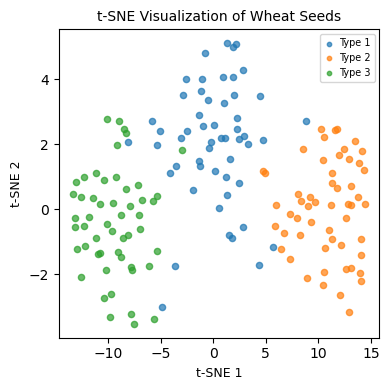

In [14]:
# Create and save the 2D t-SNE scatter plot with a smaller legend
import os
import matplotlib.pyplot as plt

os.makedirs("plots", exist_ok=True)

plt.figure(figsize=(4, 4))

for class_label in sorted(y_train.unique()):
    mask = y_train.to_numpy() == class_label
    plt.scatter(
        X_train_tsne[mask, 0],
        X_train_tsne[mask, 1],
        label=f"Type {class_label}",
        alpha=0.7,
        s=20
    )

plt.xlabel("t-SNE 1", fontsize=9)
plt.ylabel("t-SNE 2", fontsize=9)
plt.title("t-SNE Visualization of Wheat Seeds", fontsize=10)

plt.legend(
    fontsize=7,
    markerscale=0.7,
    handlelength=1.2,
    handletextpad=0.4
)

plt.tight_layout()
plt.savefig("plots/tsne_plot.png", dpi=300, bbox_inches="tight")
plt.show()

In [15]:
# Train SVM models using linear, polynomial, and RBF kernels
from sklearn.svm import SVC

svm_linear = SVC(kernel="linear")
svm_poly = SVC(kernel="poly")
svm_rbf = SVC(kernel="rbf")

svm_linear.fit(X_train_scaled, y_train)
svm_poly.fit(X_train_scaled, y_train)
svm_rbf.fit(X_train_scaled, y_train)

print("All three SVM models trained successfully.")

All three SVM models trained successfully.


In [16]:
# Generate test-set predictions using all three SVM models
y_pred_linear = svm_linear.predict(X_test_scaled)
y_pred_poly = svm_poly.predict(X_test_scaled)
y_pred_rbf = svm_rbf.predict(X_test_scaled)

print("Linear SVM predictions:", y_pred_linear[:10])
print("Polynomial SVM predictions:", y_pred_poly[:10])
print("RBF SVM predictions:", y_pred_rbf[:10])

Linear SVM predictions: [3 1 2 2 1 3 2 3 3 2]
Polynomial SVM predictions: [1 1 1 2 1 3 2 3 3 1]
RBF SVM predictions: [3 1 2 2 1 3 2 3 3 2]


In [17]:
# Calculate evaluation metrics for all three SVM models
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

svm_results = []

for name, y_pred in [
    ("Linear SVM", y_pred_linear),
    ("Polynomial SVM", y_pred_poly),
    ("RBF SVM", y_pred_rbf)
]:
    svm_results.append([
        name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, average="weighted"),
        recall_score(y_test, y_pred, average="weighted"),
        f1_score(y_test, y_pred, average="weighted")
    ])

print("Model\t\tAccuracy\tPrecision\tRecall\t\tF1-score")
for result in svm_results:
    print(f"{result[0]}\t{result[1]:.4f}\t\t{result[2]:.4f}\t\t{result[3]:.4f}\t\t{result[4]:.4f}")

Model		Accuracy	Precision	Recall		F1-score
Linear SVM	0.9250		0.9247		0.9250		0.9240
Polynomial SVM	0.8250		0.8863		0.8250		0.8303
RBF SVM	0.8750		0.8744		0.8750		0.8739


In [18]:
# Create confusion matrices for the three SVM models
from sklearn.metrics import confusion_matrix

cm_linear = confusion_matrix(y_test, y_pred_linear)
cm_poly = confusion_matrix(y_test, y_pred_poly)
cm_rbf = confusion_matrix(y_test, y_pred_rbf)

print("Linear SVM Confusion Matrix:")
print(cm_linear)

print("\nPolynomial SVM Confusion Matrix:")
print(cm_poly)

print("\nRBF SVM Confusion Matrix:")
print(cm_rbf)

Linear SVM Confusion Matrix:
[[11  1  1]
 [ 1 13  0]
 [ 0  0 13]]

Polynomial SVM Confusion Matrix:
[[13  0  0]
 [ 4 10  0]
 [ 3  0 10]]

RBF SVM Confusion Matrix:
[[10  1  2]
 [ 1 13  0]
 [ 1  0 12]]


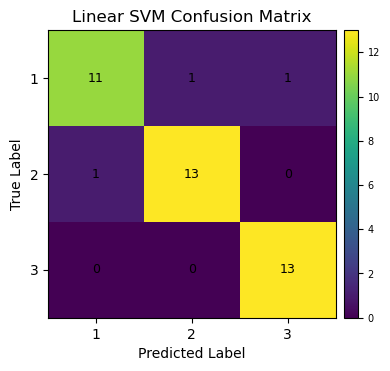

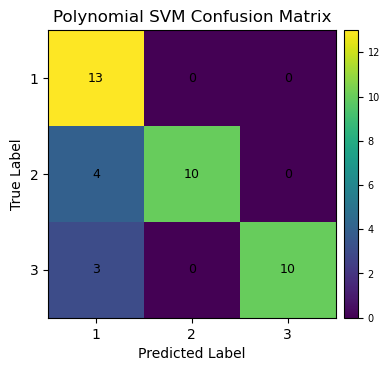

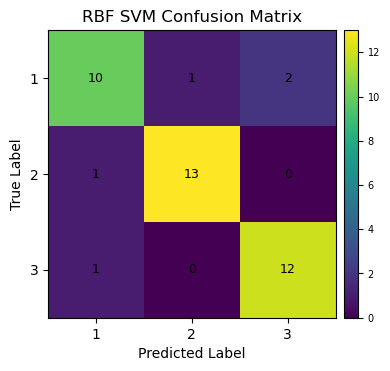

In [19]:
# Save each SVM confusion matrix with a same-height colorbar
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from mpl_toolkits.axes_grid1 import make_axes_locatable

svm_cms = {
    "Linear_SVM": cm_linear,
    "Polynomial_SVM": cm_poly,
    "RBF_SVM": cm_rbf
}

for name, cm in svm_cms.items():
    fig, ax = plt.subplots(figsize=(4, 4))

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.08)

    im = ax.imshow(cm, interpolation="nearest")

    ax.set(
        xticks=[0, 1, 2],
        yticks=[0, 1, 2],
        xticklabels=[1, 2, 3],
        yticklabels=[1, 2, 3],
        xlabel="Predicted Label",
        ylabel="True Label",
        title=name.replace("_", " ") + " Confusion Matrix"
    )

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j, i, cm[i, j],
                ha="center",
                va="center",
                fontsize=9
            )

    fig.colorbar(im, cax=cax)
    cax.tick_params(labelsize=7)

    plt.tight_layout()
    plt.savefig(
        f"plots/{name}_confusion_matrix.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()
    plt.close()

In [20]:
# Train Decision Tree models with different max_depth and min_samples_split values
from sklearn.tree import DecisionTreeClassifier

dt_models = {
    "DT_D3_S2": DecisionTreeClassifier(max_depth=3, min_samples_split=2, random_state=42),
    "DT_D5_S2": DecisionTreeClassifier(max_depth=5, min_samples_split=2, random_state=42),
    "DT_D10_S2": DecisionTreeClassifier(max_depth=10, min_samples_split=2, random_state=42),
    "DT_D5_S5": DecisionTreeClassifier(max_depth=5, min_samples_split=5, random_state=42),
    "DT_D5_S10": DecisionTreeClassifier(max_depth=5, min_samples_split=10, random_state=42)
}

for model in dt_models.values():
    model.fit(X_train, y_train)

print("All Decision Tree models trained successfully.")

All Decision Tree models trained successfully.


In [21]:
# Generate test-set predictions using all Decision Tree models
dt_predictions = {}

for name, model in dt_models.items():
    dt_predictions[name] = model.predict(X_test)

for name, predictions in dt_predictions.items():
    print(name, ":", predictions[:10])

DT_D3_S2 : [3 1 2 2 1 3 2 3 3 2]
DT_D5_S2 : [1 1 2 2 1 3 2 3 3 2]
DT_D10_S2 : [1 1 2 2 1 3 2 3 3 2]
DT_D5_S5 : [1 1 2 2 1 3 2 3 3 2]
DT_D5_S10 : [3 1 2 2 1 3 2 3 3 2]


In [22]:
# Calculate evaluation metrics for all Decision Tree models
dt_results = []

for name, y_pred in dt_predictions.items():
    dt_results.append([
        name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, average="weighted"),
        recall_score(y_test, y_pred, average="weighted"),
        f1_score(y_test, y_pred, average="weighted")
    ])

print("Model\t\tAccuracy\tPrecision\tRecall\t\tF1-score")

for result in dt_results:
    print(f"{result[0]}\t{result[1]:.4f}\t\t{result[2]:.4f}\t\t{result[3]:.4f}\t\t{result[4]:.4f}")

Model		Accuracy	Precision	Recall		F1-score
DT_D3_S2	0.8000		0.8076		0.8000		0.8009
DT_D5_S2	0.8250		0.8409		0.8250		0.8259
DT_D10_S2	0.8250		0.8409		0.8250		0.8259
DT_D5_S5	0.8250		0.8409		0.8250		0.8259
DT_D5_S10	0.8000		0.8076		0.8000		0.8009


In [23]:
# Create confusion matrices for all Decision Tree models
dt_confusion_matrices = {}

for name, y_pred in dt_predictions.items():
    dt_confusion_matrices[name] = confusion_matrix(y_test, y_pred)

for name, cm in dt_confusion_matrices.items():
    print(f"\n{name} Confusion Matrix:")
    print(cm)


DT_D3_S2 Confusion Matrix:
[[10  1  2]
 [ 1 13  0]
 [ 4  0  9]]

DT_D5_S2 Confusion Matrix:
[[11  1  1]
 [ 1 13  0]
 [ 4  0  9]]

DT_D10_S2 Confusion Matrix:
[[11  1  1]
 [ 1 13  0]
 [ 4  0  9]]

DT_D5_S5 Confusion Matrix:
[[11  1  1]
 [ 1 13  0]
 [ 4  0  9]]

DT_D5_S10 Confusion Matrix:
[[10  1  2]
 [ 1 13  0]
 [ 4  0  9]]


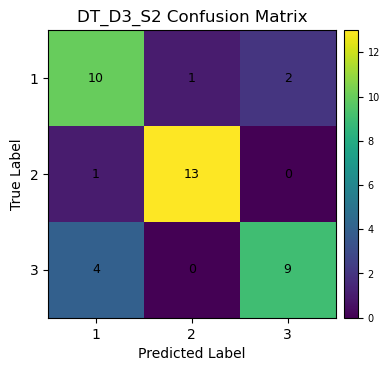

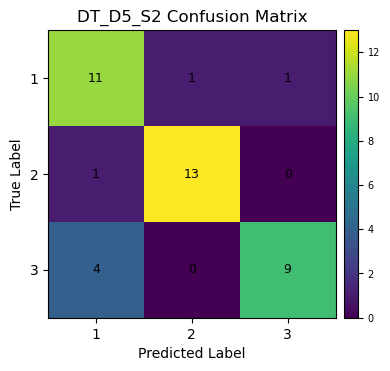

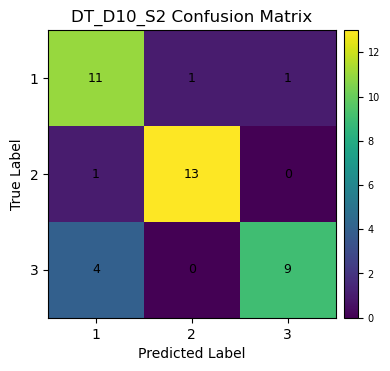

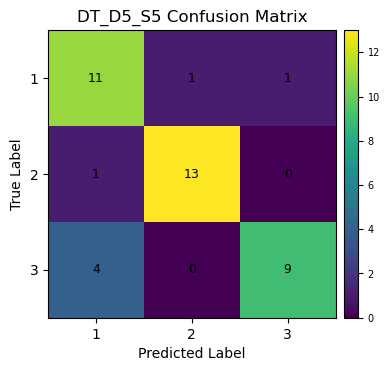

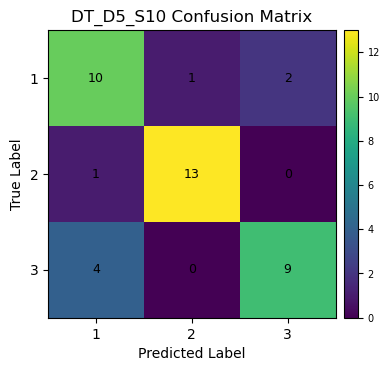

In [24]:
# Save each Decision Tree confusion matrix with a same-height colorbar
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

for name, cm in dt_confusion_matrices.items():
    fig, ax = plt.subplots(figsize=(4, 4))

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.08)

    im = ax.imshow(cm, interpolation="nearest")

    ax.set(
        xticks=[0, 1, 2],
        yticks=[0, 1, 2],
        xticklabels=[1, 2, 3],
        yticklabels=[1, 2, 3],
        xlabel="Predicted Label",
        ylabel="True Label",
        title=name + " Confusion Matrix"
    )

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j, i, cm[i, j],
                ha="center",
                va="center",
                fontsize=9
            )

    fig.colorbar(im, cax=cax)
    cax.tick_params(labelsize=7)

    plt.tight_layout()
    plt.savefig(
        f"plots/{name}_confusion_matrix.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()
    plt.close()

In [25]:
# Measure training and prediction time for all classification models
import time

execution_results = []

for name, kernel in [("Linear SVM", "linear"), ("Polynomial SVM", "poly"), ("RBF SVM", "rbf")]:
    start = time.perf_counter()
    model = SVC(kernel=kernel)
    model.fit(X_train_scaled, y_train)
    training_time = time.perf_counter() - start

    start = time.perf_counter()
    model.predict(X_test_scaled)
    prediction_time = time.perf_counter() - start

    execution_results.append([name, training_time, prediction_time])

for name, model in dt_models.items():
    start = time.perf_counter()
    model.fit(X_train, y_train)
    training_time = time.perf_counter() - start

    start = time.perf_counter()
    model.predict(X_test)
    prediction_time = time.perf_counter() - start

    execution_results.append([name, training_time, prediction_time])

print("Model\t\t\tTraining Time (s)\tPrediction Time (s)")

for result in execution_results:
    print(f"{result[0]:<20}\t{result[1]:.6f}\t\t{result[2]:.6f}")

Model			Training Time (s)	Prediction Time (s)
Linear SVM          	0.003529		0.000639
Polynomial SVM      	0.001615		0.000981
RBF SVM             	0.005006		0.001542
DT_D3_S2            	0.005583		0.002964
DT_D5_S2            	0.004359		0.001794
DT_D10_S2           	0.004115		0.001663
DT_D5_S5            	0.004986		0.002943
DT_D5_S10           	0.005691		0.001986


In [26]:
# Measure CPU and memory usage during model training
import psutil
import time

resource_results = []

models_for_resource = {
    "Linear SVM": (SVC(kernel="linear"), X_train_scaled),
    "Polynomial SVM": (SVC(kernel="poly"), X_train_scaled),
    "RBF SVM": (SVC(kernel="rbf"), X_train_scaled),
    "DT_D3_S2": (dt_models["DT_D3_S2"], X_train),
    "DT_D5_S2": (dt_models["DT_D5_S2"], X_train),
    "DT_D10_S2": (dt_models["DT_D10_S2"], X_train),
    "DT_D5_S5": (dt_models["DT_D5_S5"], X_train),
    "DT_D5_S10": (dt_models["DT_D5_S10"], X_train)
}

for name, (model, data) in models_for_resource.items():
    process = psutil.Process()
    memory_before = process.memory_info().rss / (1024 ** 2)

    start = time.perf_counter()
    model.fit(data, y_train)
    training_time = time.perf_counter() - start

    memory_after = process.memory_info().rss / (1024 ** 2)
    memory_used = memory_after - memory_before

    resource_results.append([
        name,
        training_time,
        memory_used
    ])

print("Model\t\t\tTraining Time (s)\tMemory Used (MB)")

for result in resource_results:
    print(f"{result[0]:<20}\t{result[1]:.6f}\t\t{result[2]:.4f}")

Model			Training Time (s)	Memory Used (MB)
Linear SVM          	0.003954		0.0000
Polynomial SVM      	0.004673		0.0000
RBF SVM             	0.005104		0.0000
DT_D3_S2            	0.005407		0.0000
DT_D5_S2            	0.005516		0.0000
DT_D10_S2           	0.005606		0.0000
DT_D5_S5            	0.005454		0.0000
DT_D5_S10           	0.004252		0.0000


In [27]:
# Create the final comparison table for all classification models
import pandas as pd

final_results = []

for result in svm_results:
    final_results.append([
        result[0], result[1], result[2], result[3], result[4]
    ])

for result in dt_results:
    final_results.append([
        result[0], result[1], result[2], result[3], result[4]
    ])

comparison_df = pd.DataFrame(
    final_results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1-score"]
)

print(comparison_df.to_string(index=False))

         Model  Accuracy  Precision  Recall  F1-score
    Linear SVM     0.925   0.924702   0.925  0.923963
Polynomial SVM     0.825   0.886250   0.825  0.830336
       RBF SVM     0.875   0.874405   0.875  0.873889
      DT_D3_S2     0.800   0.807576   0.800  0.800893
      DT_D5_S2     0.825   0.840938   0.825  0.825900
     DT_D10_S2     0.825   0.840938   0.825  0.825900
      DT_D5_S5     0.825   0.840938   0.825  0.825900
     DT_D5_S10     0.800   0.807576   0.800  0.800893


In [28]:
# Combine model performance, execution time, and memory usage
resource_df = pd.DataFrame(
    resource_results,
    columns=["Model", "Training Time (s)", "Memory Used (MB)"]
)

final_comparison = comparison_df.merge(resource_df, on="Model")

print(final_comparison.to_string(index=False))

         Model  Accuracy  Precision  Recall  F1-score  Training Time (s)  Memory Used (MB)
    Linear SVM     0.925   0.924702   0.925  0.923963           0.003954               0.0
Polynomial SVM     0.825   0.886250   0.825  0.830336           0.004673               0.0
       RBF SVM     0.875   0.874405   0.875  0.873889           0.005104               0.0
      DT_D3_S2     0.800   0.807576   0.800  0.800893           0.005407               0.0
      DT_D5_S2     0.825   0.840938   0.825  0.825900           0.005516               0.0
     DT_D10_S2     0.825   0.840938   0.825  0.825900           0.005606               0.0
      DT_D5_S5     0.825   0.840938   0.825  0.825900           0.005454               0.0
     DT_D5_S10     0.800   0.807576   0.800  0.800893           0.004252               0.0


In [29]:
# Identify the best model based on F1-score
best_model = final_comparison.loc[final_comparison["F1-score"].idxmax()]

print("Best Model:", best_model["Model"])
print("Accuracy:", round(best_model["Accuracy"], 4))
print("Precision:", round(best_model["Precision"], 4))
print("Recall:", round(best_model["Recall"], 4))
print("F1-score:", round(best_model["F1-score"], 4))
print("Training Time (s):", round(best_model["Training Time (s)"], 6))
print("Memory Used (MB):", round(best_model["Memory Used (MB)"], 4))

Best Model: Linear SVM
Accuracy: 0.925
Precision: 0.9247
Recall: 0.925
F1-score: 0.924
Training Time (s): 0.003954
Memory Used (MB): 0.0


In [30]:
# Save the final model comparison results as a CSV file
final_comparison.to_csv("final_model_comparison.csv", index=False)

print("Final results saved as final_model_comparison.csv")

Final results saved as final_model_comparison.csv
